# 03 — Calendario y estacionalidad

Tercer notebook de la cadena. Lee `panel_diario`, `ventana_activa`,
`huecos_calendario`/`calendario_habil` de `01_calidad_y_panel` y
`dim_producto_priorizado` de `02_regla_priorizacion` (por los lectores de
`common_priorizacion.py`) -- no recalcula el panel ni las condiciones de
la regla. Audita `dim_tiempo`, construye un calendario de eventos propio
con ventanas correctas (Semana Santa derivada de fechas reales, no
hardcodeada), mide los efectos de calendario con una regresión (no una
media móvil centrada, que fuerza a 1,0 cualquier evento largo), y valida
cuantitativamente la condición 5 (temporada).

**Cadena**: `01_calidad_y_panel` → `02_regla_priorizacion` →
**`03_calendario_estacionalidad`** → `04_demanda_y_baseline` → `05_sintesis`.

In [1]:
import sys
sys.path.insert(0, '.')
from common_priorizacion import (
    PARAMS, DW, registrar_huella, verificar_huella,
    leer_panel, leer_ventana, leer_dim_priorizado,
    construir_df_razon, indice_dia_semana,
)

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf as acf_func

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (11, 4)


## 0. Carga

Se recargan `dim_tiempo`, `dim_producto`/`fact_ventas` (baratos, no son
artefactos exclusivos de notebooks anteriores) y se leen los artefactos de
01 y 02.

In [2]:
dim_tiempo = pd.read_csv(f'{DW}/dim_tiempo.csv', parse_dates=['fecha'])
dim_sucursal = pd.read_csv(f'{DW}/dim_sucursal.csv')
fact_ventas = pd.read_csv(
    f'{DW}/fact_ventas.csv',
    dtype={'codigo_item': str, 'sucursal': 'category', 'codigo_proveedor': 'category'},
    parse_dates=['fecha'],
)
SUCURSALES_REALES = [s for s in dim_sucursal['nombre']
                     if s not in ('SIN_SUCURSAL', 'BODEGA_CENTRAL')]  # INV-62: BODEGA_CENTRAL no vende directo
ventas = fact_ventas.loc[(~fact_ventas['es_devolucion']) & (fact_ventas['cantidad'] > 0)].copy()
ventas_reales = ventas.loc[ventas['sucursal'].isin(SUCURSALES_REALES)].copy()

verificar_huella('huella_01.json', ['panel_diario.parquet', 'ventana_activa.parquet', 'huecos_calendario.csv', 'calendario_habil.csv'])
verificar_huella('huella_02.json', ['dim_producto_priorizado.parquet'])

diario = leer_panel()
ventana = leer_ventana()
dim_producto = leer_dim_priorizado()

huecos_df_csv = pd.read_csv(f'{DW}/huecos_calendario.csv', parse_dates=['fecha'])
huecos_globales = sorted(huecos_df_csv['fecha'])
huecos_globales_set = set(huecos_globales)

cal_habil_csv = pd.read_csv(f'{DW}/calendario_habil.csv', parse_dates=['fecha'])
fechas_habiles = pd.DatetimeIndex(cal_habil_csv['fecha'])
indice_habil = pd.Series(cal_habil_csv['indice_habil'].values, index=fechas_habiles)
rango_fechas = pd.date_range(fact_ventas['fecha'].min(), fact_ventas['fecha'].max(), freq='D')

print('diario:', diario.shape, '| dim_producto (priorizado):', dim_producto.shape)
print('fechas hábiles:', len(fechas_habiles), '| huecos:', len(huecos_globales))


Huella verificada OK contra huella_01.json.
Huella verificada OK contra huella_02.json.
diario: (1417186, 5) | dim_producto (priorizado): (4414, 23)
fechas hábiles: 1060 | huecos: 35


## 1. Declaración: a 2023 le falta el bloque de febrero 2-21

El notebook anterior identificó el residuo de huecos de calendario tras
incorporar los reportes que antes faltaban de 2023 (INV-62: se agregaron
`marz abril 2023.xlsx` y `nov dic 2023.xlsx`, que cerraron por completo
los bloques de noviembre y diciembre de 2023 -- 0 días de residuo en esos
meses). Queda un único bloque grande sin explicar: **2023-02-02 a
2023-02-21 (23 días)**, un hueco genuino dentro del reporte de origen
(`en fe 2023.xlsx`), no un archivo faltante -- no hay reporte disponible
para llenarlo. A diferencia de la corrida anterior, diciembre ya se
apoya en **3 observaciones-año completas (2023, 2024, 2025)**, no 2 --
se confirma con el conteo real antes de interpretar cualquier efecto
navideño.

In [3]:
print('PARAMS["MESES_2023_INCOMPLETOS"]:', PARAMS['MESES_2023_INCOMPLETOS'])
dic_2023 = [f for f in fechas_habiles if f.year == 2023 and f.month == 12]
nov_2023 = [f for f in fechas_habiles if f.year == 2023 and f.month == 11]
feb_2023 = [f for f in fechas_habiles if f.year == 2023 and f.month == 2]
print(f'Días hábiles en noviembre 2023: {len(nov_2023)} | en diciembre 2023: {len(dic_2023)} '
      f'| en febrero 2023: {len(feb_2023)}')
assert len(dic_2023) > 0 and len(nov_2023) > 0, \
    'se esperaban días hábiles en nov/dic 2023 tras INV-62 -- revisar si el ETL se reejecutó con los reportes nuevos'
assert '2023-11' not in PARAMS['MESES_2023_INCOMPLETOS'] and '2023-12' not in PARAMS['MESES_2023_INCOMPLETOS'], \
    'MESES_2023_INCOMPLETOS de common_priorizacion.py quedó desactualizado respecto a los datos'

PARAMS["MESES_2023_INCOMPLETOS"]: ['2023-02']
Días hábiles en noviembre 2023: 30 | en diciembre 2023: 31 | en febrero 2023: 1


Confirmado: noviembre y diciembre de 2023 ya tienen días hábiles reales
(el bloque que antes forzaba 2 observaciones-año en vez de 3 quedó
cerrado). Solo febrero 2023 (`PARAMS['MESES_2023_INCOMPLETOS']`) sigue
excluido de `fechas_habiles` -- cualquier efecto de "diciembre" o "fin de
año" en este notebook se estima ahora sobre **2023, 2024 y 2025**, no solo
sobre 2024 y 2025 -- se retoma en la sección 5, en la prueba de
sensibilidad de la tendencia.

## 2. Auditoría de `dim_tiempo`

In [4]:
print('Nulos por columna en dim_tiempo (nombre_festivo nulo es esperado: solo aplica a días festivos):')
print(dim_tiempo.isna().sum())


Nulos por columna en dim_tiempo (nombre_festivo nulo es esperado: solo aplica a días festivos):
fecha                   0
anio                    0
mes                     0
dia                     0
dia_semana              0
nombre_dia              0
semana_iso              0
trimestre               0
es_fin_semana           0
es_festivo              0
nombre_festivo       1043
es_puente_festivo       0
es_quincena             0
temporada               0
dtype: int64


In [5]:
print('Ley Emiliani -- festivos movidos al lunes siguiente, marcados "(observado)":')
dim_tiempo.loc[dim_tiempo['nombre_festivo'].str.contains('observado', na=False), ['fecha', 'nombre_festivo', 'nombre_dia']].head(6)


Ley Emiliani -- festivos movidos al lunes siguiente, marcados "(observado)":


,fecha,nombre_festivo,nombre_dia
7,2023-01-09,Día de los Reyes Magos (observado),lunes
77,2023-03-20,Día de San José (observado),lunes
140,2023-05-22,Ascensión del señor (observado),lunes
161,2023-06-12,Corpus Christi (observado),lunes
168,2023-06-19,Sagrado Corazón (observado),lunes
182,2023-07-03,San Pedro y San Pablo (observado),lunes


In [6]:
print(dim_tiempo['temporada'].value_counts())
print()
print('es_quincena marca', dim_tiempo['es_quincena'].sum(), 'días -- verificado: día 15 y último día de cada mes.')


temporada
regular             351
semana_santa        183
vacaciones_mitad    183
escolar_inicio      142
navidad             110
black_friday         90
halloween            36
Name: count, dtype: int64

es_quincena marca 72 días -- verificado: día 15 y último día de cada mes.


`temporada` clasifica por **mes completo**, no por fecha móvil real:
"semana_santa" marca los 183 días de marzo+abril de los 3 años (Semana
Santa dura solo una semana), y "vacaciones_mitad" marca igual todo
junio-julio. Sirve bien para "navidad" (ventana angosta y fija: diciembre
más 6 días de enero), pero no para eventos que se mueven de fecha cada
año. Por eso este notebook no usa `dim_tiempo.temporada` para nada que
dependa de una fecha móvil -- construye `calendario_eventos.csv` aparte,
con ventanas derivadas de los festivos reales en vez de mes calendario.

## 3. Calendario de eventos con ventanas correctas

Semana Santa se deriva de las fechas reales de "Jueves Santo" que ya trae
`dim_tiempo` (Domingo de Ramos = Jueves Santo - 3 días, hasta Domingo de
Resurrección = Jueves Santo + 4 días) -- no se hardcodean fechas. El
bloque de diciembre se desagrega en novena, nochebuena/navidad, fin de año
y enero post-navidad; las primas se aproximan a los períodos de pago de
mitad de junio y de diciembre (aproximación declarada, no hay fecha exacta
de pago en el dato).

In [7]:
fechas_festivo_sorted = np.array(sorted(dim_tiempo.loc[dim_tiempo['es_festivo'], 'fecha']))
jueves_santo = dim_tiempo.loc[dim_tiempo['nombre_festivo'] == 'Jueves Santo', 'fecha']
ventanas_semana_santa = [(f - pd.Timedelta(days=3), f + pd.Timedelta(days=4)) for f in jueves_santo]

calendario = dim_tiempo[['fecha', 'dia_semana', 'nombre_dia', 'dia', 'mes', 'semana_iso',
                          'es_festivo', 'nombre_festivo', 'es_puente_festivo', 'es_quincena']].copy()
calendario['es_semana_santa'] = False
for ini, fin in ventanas_semana_santa:
    calendario.loc[calendario['fecha'].between(ini, fin), 'es_semana_santa'] = True

fechas_arr = calendario['fecha'].values
idx_prox = np.searchsorted(fechas_festivo_sorted, fechas_arr, side='left')
dias_al_proximo, dias_desde_ultimo = [], []
for i, f in enumerate(fechas_arr):
    j = idx_prox[i]
    dias_al_proximo.append((fechas_festivo_sorted[j] - f) / np.timedelta64(1, 'D') if j < len(fechas_festivo_sorted) else np.nan)
    dias_desde_ultimo.append((f - fechas_festivo_sorted[j - 1]) / np.timedelta64(1, 'D') if j > 0 else np.nan)
calendario['dias_al_proximo_festivo'] = dias_al_proximo
calendario['dias_desde_ultimo_festivo'] = dias_desde_ultimo
calendario['es_vispera_festivo'] = calendario['dias_al_proximo_festivo'] == 1
calendario['es_resaca_festivo'] = calendario['dias_desde_ultimo_festivo'] == 1

def bloque_diciembre(row):
    ini, fin = PARAMS['DICIEMBRE_NOVENA']
    if row['mes'] == 12 and ini <= row['dia'] <= fin:
        return 'novena'
    if row['mes'] == 12 and row['dia'] in PARAMS['DICIEMBRE_NOCHEBUENA_NAVIDAD']:
        return 'nochebuena_navidad'
    if row['mes'] == 12 and row['dia'] in PARAMS['DICIEMBRE_FIN_DE_ANIO']:
        return 'fin_de_anio'
    if row['mes'] == 1 and row['dia'] <= PARAMS['ENERO_POSTNAVIDAD_MAX_DIA']:
        return 'enero_postnavidad'
    return 'ninguno'

calendario['bloque_diciembre'] = calendario.apply(bloque_diciembre, axis=1)
ini_jun, fin_jun = PARAMS['PERIODO_PRIMA_JUNIO']
ini_dic, fin_dic = PARAMS['PERIODO_PRIMA_DICIEMBRE']
calendario['es_periodo_prima'] = (
    ((calendario['mes'] == 6) & calendario['dia'].between(ini_jun, fin_jun))
    | ((calendario['mes'] == 12) & calendario['dia'].between(ini_dic, fin_dic))
)
calendario['es_navidad'] = (calendario['mes'] == 12) | ((calendario['mes'] == 1) & (calendario['dia'] <= PARAMS['ENERO_POSTNAVIDAD_MAX_DIA']))
calendario.to_csv(f'{DW}/calendario_eventos.csv', index=False)
print('guardado:', f'{DW}/calendario_eventos.csv', calendario.shape)
calendario.loc[calendario['es_semana_santa'], ['fecha', 'nombre_dia']].groupby(calendario['fecha'].dt.year).agg(['min', 'max'])


guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/calendario_eventos.csv (1095, 18)


fecha            nombre_dia         
             min        max        min      max
fecha                                          
2023  2023-04-03 2023-04-10    domingo  viernes
2024  2024-03-25 2024-04-01    domingo  viernes
2025  2025-04-14 2025-04-21    domingo  viernes

In [8]:
# Conteo real de días hábiles por bloque de diciembre -- confirma cuántas
# observaciones-año sostienen cada efecto (sección 1: 2023 no aporta nada aquí).
cal_habil_idx = calendario.set_index('fecha').reindex(fechas_habiles)
conteo_bloques = cal_habil_idx['bloque_diciembre'].value_counts()
print(conteo_bloques)
print()
for bloque in ['novena', 'nochebuena_navidad', 'fin_de_anio', 'enero_postnavidad']:
    anios = sorted(cal_habil_idx.loc[cal_habil_idx['bloque_diciembre'] == bloque].index.year.unique())
    print(f'{bloque}: años con datos = {anios}')


bloque_diciembre
ninguno               1009
novena                  24
enero_postnavidad       15
nochebuena_navidad       6
fin_de_anio              6
Name: count, dtype: int64

novena: años con datos = [2023, 2024, 2025]
nochebuena_navidad: años con datos = [2023, 2024, 2025]
fin_de_anio: años con datos = [2023, 2024, 2025]
enero_postnavidad: años con datos = [2023, 2024, 2025]


## 4. Índices estacionales sobre calendario hábil (día de semana, categoría×sucursal, día del mes, semana del año)

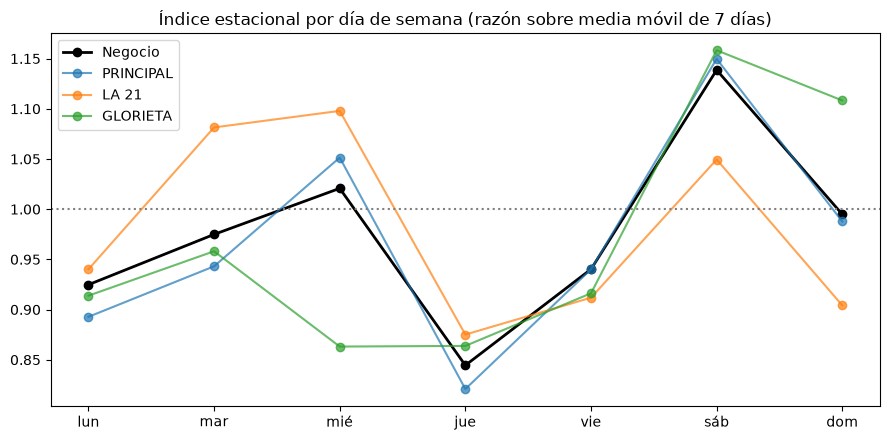

Diferencia máxima entre sucursales en un mismo día de semana: 0.23 puntos de índice.


In [9]:
ventas_habil = ventas_reales.loc[~ventas_reales['fecha'].isin(huecos_globales_set)]
serie_negocio = ventas_habil.groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
df_negocio_diario = construir_df_razon(serie_negocio)
idx_negocio = indice_dia_semana(df_negocio_diario)

idx_sucursal = {}
for suc in SUCURSALES_REALES:
    s = ventas_habil.loc[ventas_habil['sucursal'] == suc].groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
    idx_sucursal[suc] = indice_dia_semana(construir_df_razon(s))
idx_sucursal_df = pd.DataFrame(idx_sucursal)

nombres_dia_iso = {1: 'lun', 2: 'mar', 3: 'mié', 4: 'jue', 5: 'vie', 6: 'sáb', 7: 'dom'}
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(idx_negocio.index.map(nombres_dia_iso), idx_negocio.values, marker='o', linewidth=2, color='black', label='Negocio')
for suc in SUCURSALES_REALES:
    ax.plot(idx_sucursal_df.index.map(nombres_dia_iso), idx_sucursal_df[suc], marker='o', alpha=0.7, label=suc)
ax.axhline(1.0, color='gray', linestyle=':')
ax.set_title('Índice estacional por día de semana (razón sobre media móvil de 7 días)')
ax.legend()
plt.tight_layout()
plt.show()

diferencia_max_sucursal = (idx_sucursal_df.max(axis=1) - idx_sucursal_df.min(axis=1)).max()
print(f'Diferencia máxima entre sucursales en un mismo día de semana: {diferencia_max_sucursal:.2f} puntos de índice.')


Con una diferencia de este tamaño, las sucursales **no son homogéneas**
en su patrón semanal -- un modelo de demanda que use un solo perfil de día
de semana para las tres sucursales estaría promediando perfiles distintos.
Se retoma con el mismo criterio para categoría×sucursal a continuación.

In [10]:
# Índice categoría x sucursal, para las categorías que concentran las
# condiciones 1-5 (mismo criterio que usará la fuerza estacional más abajo).
categorias_prioritarias_preliminar = dim_producto.loc[
    dim_producto[['cond1_espacio_bodega', 'cond2_perecedero', 'cond3_refrigerado', 'cond4_papel_higienico', 'cond5_temporada']].any(axis=1),
    'categoria'
].value_counts().head(5).index.tolist()
print('categorías usadas para el índice categoría x sucursal y la fuerza estacional:', categorias_prioritarias_preliminar)

filas_cat_suc = []
for cat in categorias_prioritarias_preliminar:
    codigos_cat = set(dim_producto.loc[dim_producto['categoria'] == cat, 'codigo_item'])
    for suc in SUCURSALES_REALES:
        s = ventas_habil.loc[(ventas_habil['sucursal'] == suc) & (ventas_habil['codigo_item'].isin(codigos_cat))]
        s = s.groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
        idx = indice_dia_semana(construir_df_razon(s))
        for dia, valor in idx.items():
            filas_cat_suc.append({'categoria': cat, 'sucursal': suc, 'dia_semana': dia, 'indice': valor})

estacionalidad_indices_categoria_sucursal = pd.DataFrame(filas_cat_suc)
estacionalidad_indices_categoria_sucursal.to_csv(f'{DW}/estacionalidad_indices_categoria_sucursal.csv', index=False)
idx_sucursal_df.to_csv(f'{DW}/estacionalidad_indices_dia_semana_sucursal.csv')
print('guardado: estacionalidad_indices_categoria_sucursal.csv', estacionalidad_indices_categoria_sucursal.shape)


categorías usadas para el índice categoría x sucursal y la fuerza estacional: ['Lácteos', 'Licores', 'Cárnicos', 'Frutas y verduras', 'Mariscos']


guardado: estacionalidad_indices_categoria_sucursal.csv (105, 4)


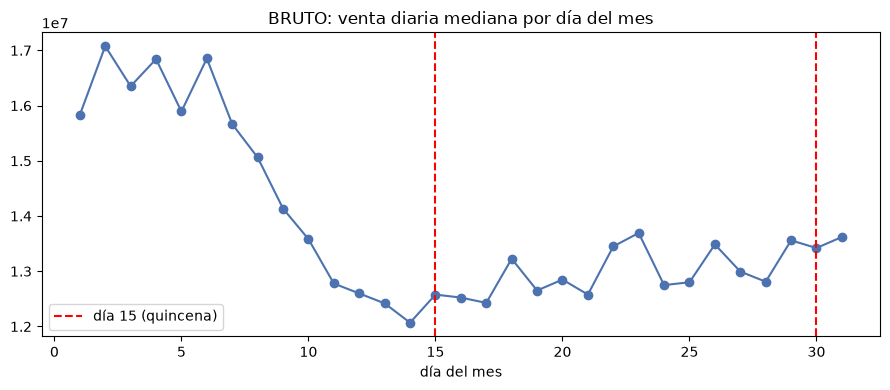

El control riguroso (por regresión, no por media móvil) de los tramos de inicio/quincena/fin de mes se hace en la sección 5, junto con los demás efectos de calendario, usando el mismo método.


In [11]:
df_mes = pd.DataFrame({'valor': serie_negocio.values}, index=serie_negocio.index)
df_mes['dia_del_mes'] = df_mes.index.day
curva_dia_mes = df_mes.groupby('dia_del_mes')['valor'].median()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(curva_dia_mes.index, curva_dia_mes.values, marker='o', color='#4c72b0')
ax.axvline(15, color='red', linestyle='--', label='día 15 (quincena)')
ax.axvline(30, color='red', linestyle='--')
ax.set_title('BRUTO: venta diaria mediana por día del mes')
ax.set_xlabel('día del mes')
ax.legend()
plt.tight_layout()
plt.show()
print('El control riguroso (por regresión, no por media móvil) de los tramos de inicio/quincena/fin de mes se hace',
      'en la sección 5, junto con los demás efectos de calendario, usando el mismo método.')


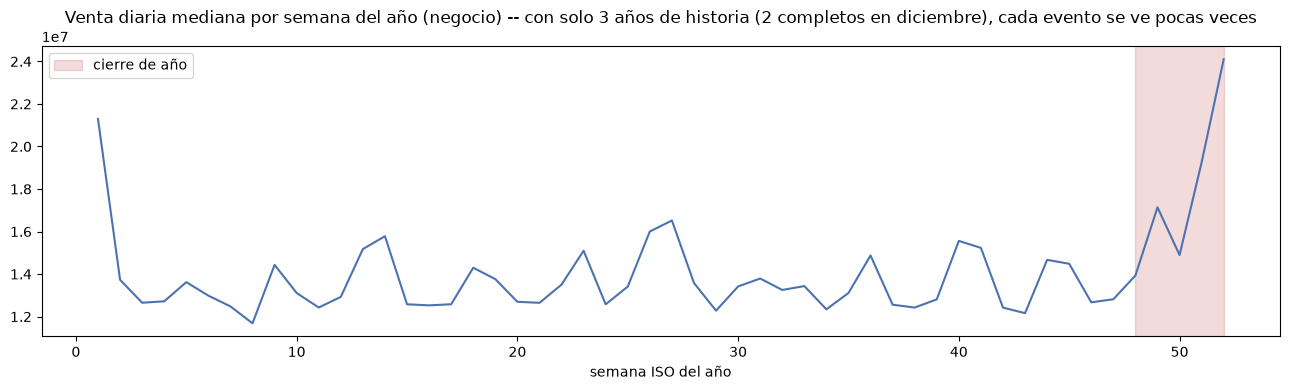

guardado: estacionalidad_indices*.csv


In [12]:
df_sem = pd.DataFrame({'valor': serie_negocio.values}, index=serie_negocio.index)
df_sem['semana_iso'] = df_sem.index.isocalendar().week.values
curva_semana_anio = df_sem.groupby('semana_iso')['valor'].median()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(curva_semana_anio.index, curva_semana_anio.values, color='#4c72b0')
ax.axvspan(48, 52, color='#c44e52', alpha=0.2, label='cierre de año')
ax.set_title('Venta diaria mediana por semana del año (negocio) -- con solo 3 años de historia (2 completos en diciembre), cada evento se ve pocas veces')
ax.set_xlabel('semana ISO del año')
ax.legend()
plt.tight_layout()
plt.show()

estacionalidad_indices = pd.DataFrame({
    'dia_semana': idx_negocio.index, 'indice_negocio': idx_negocio.values,
}).merge(idx_sucursal_df.reset_index().rename(columns={'index': 'dia_semana'}), on='dia_semana', how='left')
estacionalidad_indices.to_csv(f'{DW}/estacionalidad_indices.csv', index=False)
# Nombradas "curva_bruta_*", no "índice_*": son medianas brutas en pesos,
# sin controlar por día de semana ni tendencia -- el control riguroso del
# día del mes vive en efectos_calendario.csv (es_inicio_mes/es_quincena_ppal/es_fin_mes, sección 5).
curva_dia_mes.to_frame('venta_mediana').to_csv(f'{DW}/curva_bruta_dia_mes.csv')
curva_semana_anio.to_frame('venta_mediana').to_csv(f'{DW}/curva_bruta_semana_anio.csv')
print('guardado: estacionalidad_indices*.csv')


## 5. Efecto festivo, Semana Santa, diciembre desagregado y primas

Medir cada evento por separado, comparando contra un modelo ajustado sin
él, ignora que las banderas de calendario **se solapan**: `Período de
prima` (dic 1-20) y `novena` (dic 16-23) comparten 5 días, y un día puede
ser víspera de festivo, período de prima e inicio de mes a la vez -- un
efecto medido así no es realmente parcial. Se usa en su lugar **una sola
regresión con todas las banderas como regresores simultáneos, sobre todos
los días**: los coeficientes sí son efectos parciales, y se obtienen
**intervalos de confianza** -- la medida de incertidumbre que hace falta
con apenas 2 años de evidencia para diciembre (sección 1), en vez de un
punto estimado sin margen de error.

El día de referencia implícito (todas las banderas en 0) es un día de
mitad de mes de un mes ordinario (feb-nov), sin festivo ni puente.

In [13]:
cal_idx = calendario.set_index('fecha').reindex(fechas_habiles)
dia_del_mes = cal_idx.index.day
mes_ = cal_idx.index.month
mes_ordinario = mes_.isin(range(2, 12))

df_reg = pd.DataFrame({'fecha': fechas_habiles, 'valor': serie_negocio.values})
df_reg['dia_semana'] = df_reg['fecha'].map(lambda f: f.isoweekday()).astype(str)
df_reg['t'] = np.arange(len(df_reg))
df_reg['t2'] = df_reg['t'] ** 2
df_reg['log_valor'] = np.log(df_reg['valor'].clip(lower=1))

df_reg['es_festivo'] = cal_idx['es_festivo'].fillna(False).astype(int).values
df_reg['es_vispera'] = cal_idx['es_vispera_festivo'].fillna(False).astype(int).values
df_reg['es_resaca'] = cal_idx['es_resaca_festivo'].fillna(False).astype(int).values
df_reg['es_puente'] = cal_idx['es_puente_festivo'].fillna(False).astype(int).values
df_reg['es_semana_santa'] = cal_idx['es_semana_santa'].fillna(False).astype(int).values
df_reg['es_prima'] = cal_idx['es_periodo_prima'].fillna(False).astype(int).values
df_reg['bloque_diciembre'] = cal_idx['bloque_diciembre'].fillna('ninguno').values
df_reg['es_inicio_mes'] = ((dia_del_mes <= 3) & mes_ordinario).astype(int)
df_reg['es_quincena_ppal'] = (np.isin(dia_del_mes, [15, 16, 17]) & mes_ordinario).astype(int)
df_reg['es_fin_mes'] = ((dia_del_mes >= 28) & mes_ordinario).astype(int)

FLAGS_SIMPLES = ['es_festivo', 'es_vispera', 'es_resaca', 'es_puente', 'es_semana_santa', 'es_prima',
                  'es_inicio_mes', 'es_quincena_ppal', 'es_fin_mes']
NIVELES_DICIEMBRE = ['novena', 'nochebuena_navidad', 'fin_de_anio', 'enero_postnavidad']
DURACION_DIAS_EVENTO = {
    'es_festivo': 1, 'es_vispera': 1, 'es_resaca': 1, 'es_puente': 2, 'es_semana_santa': 8, 'es_prima': 20,
    'novena': 8, 'nochebuena_navidad': 2, 'fin_de_anio': 2, 'enero_postnavidad': 6,
    'es_inicio_mes': 3, 'es_quincena_ppal': 3, 'es_fin_mes': 3,
}
ETIQUETAS = {
    'es_festivo': 'Festivo', 'es_vispera': 'Víspera de festivo', 'es_resaca': 'Resaca de festivo',
    'es_puente': 'Puente festivo', 'es_semana_santa': 'Semana Santa', 'es_prima': 'Período de prima',
    'es_inicio_mes': 'Inicio de mes (1-3)', 'es_quincena_ppal': 'Quincena (15-17)', 'es_fin_mes': 'Fin de mes (>=28)',
    'novena': 'novena', 'nochebuena_navidad': 'nochebuena_navidad', 'fin_de_anio': 'fin_de_anio', 'enero_postnavidad': 'enero_postnavidad',
}

formula = ('log_valor ~ C(dia_semana) + t + t2 + ' + ' + '.join(FLAGS_SIMPLES)
           + ' + C(bloque_diciembre, Treatment("ninguno"))')
modelo_conjunto = smf.ols(formula, data=df_reg).fit()
print(f'R² del modelo conjunto (todas las banderas simultáneas, todos los días): {modelo_conjunto.rsquared:.3f}')


R² del modelo conjunto (todas las banderas simultáneas, todos los días): 0.413


Un R² de este orden es esperable: el modelo solo tiene día de semana,
tendencia y las banderas de calendario -- no pretende explicar toda la
varianza de la venta diaria, solo aislar efectos parciales limpios de
solapamiento entre eventos.

In [14]:
# Modelo auxiliar sin ningún día de evento -- lo usa la verificación de
# festivo+puente (sección 5.1) y la de enero_postnavidad (más abajo), donde
# interesa el residuo de un solo evento fuera del modelo conjunto.
es_algun_evento = (
    df_reg[FLAGS_SIMPLES].any(axis=1) | (df_reg['bloque_diciembre'] != 'ninguno')
)
modelo_no_evento = smf.ols('log_valor ~ C(dia_semana) + t + t2', data=df_reg.loc[~es_algun_evento]).fit()
df_reg['residuo_log_no_evento'] = df_reg['log_valor'] - modelo_no_evento.predict(df_reg)


In [15]:
# Extracción de efectos parciales + IC del modelo conjunto -- para las
# banderas simples el nombre del parámetro es directo; para bloque_diciembre
# (categórica) patsy genera 'C(bloque_diciembre, Treatment("ninguno"))[T.<nivel>]'.
def nombre_param_diciembre(nivel):
    for p in modelo_conjunto.params.index:
        if p.startswith('C(bloque_diciembre') and p.endswith(f'[T.{nivel}]'):
            return p
    raise KeyError(nivel)

filas = []
for col in FLAGS_SIMPLES:
    filas.append((col, col))
for nivel in NIVELES_DICIEMBRE:
    filas.append((nombre_param_diciembre(nivel), nivel))

ic = modelo_conjunto.conf_int()
registros = []
for param, evento in filas:
    coef = modelo_conjunto.params[param]
    flag_col = evento if evento in df_reg.columns else (df_reg['bloque_diciembre'] == evento)
    flag_vals = df_reg[evento].values.astype(bool) if evento in df_reg.columns else (df_reg['bloque_diciembre'] == evento).values
    n_dias = int(flag_vals.sum())
    n_anios = int(df_reg.loc[flag_vals, 'fecha'].dt.year.nunique())
    controlado_x = float(np.exp(coef))
    ic_bajo, ic_alto = float(np.exp(ic.loc[param, 0])), float(np.exp(ic.loc[param, 1]))
    bruto_x = float(serie_negocio.loc[flag_vals].mean() / serie_negocio.loc[~es_algun_evento.values].mean())
    registros.append({
        'evento': ETIQUETAS[evento], 'tipo': 'bloque_diciembre' if evento in NIVELES_DICIEMBRE else ('tramo_del_mes' if evento in ('es_inicio_mes', 'es_quincena_ppal', 'es_fin_mes') else 'festivo'),
        'controlado_x': round(controlado_x, 3), 'ic_bajo': round(ic_bajo, 3), 'ic_alto': round(ic_alto, 3),
        'bruto_vs_dia_ordinario_x': round(bruto_x, 3),
        'n_dias': n_dias, 'n_anios_evidencia': n_anios, 'duracion_dias': DURACION_DIAS_EVENTO[evento],
        'sensible_a_especificacion': bool((ic_alto - ic_bajo) > 0.3),
        'direccion': 'sube' if ic_bajo > 1 else ('baja' if ic_alto < 1 else 'sin_efecto_claro (IC cruza 1.0)'),
    })

efectos_calendario = pd.DataFrame(registros)
efectos_calendario['metodo'] = 'regresion_conjunta_todas_las_banderas_ols_log'
efectos_calendario.to_csv(f'{DW}/efectos_calendario.csv', index=False)
print('guardado:', f'{DW}/efectos_calendario.csv', efectos_calendario.shape)
efectos_calendario.sort_values('controlado_x', ascending=False)


guardado: /home/ddelgadillo@redcorporativa.corpoica.org.co/otros/etl/InventaIO/data/processed_real/efectos_calendario.csv (13, 12)


,evento,tipo,controlado_x,ic_bajo,ic_alto,bruto_vs_dia_ordinario_x,n_dias,n_anios_evidencia,duracion_dias,sensible_a_especificacion,direccion,metodo
11,fin_de_anio,bloque_diciembre,2.53,2.06,3.12,3.12,6,3,2,True,sube,regresion_conjunta_todas_las_banderas_ols_log
10,nochebuena_navidad,bloque_diciembre,1.63,1.32,2.01,2.16,6,3,2,True,sube,regresion_conjunta_todas_las_banderas_ols_log
9,novena,bloque_diciembre,1.46,1.31,1.62,1.58,24,3,8,True,sube,regresion_conjunta_todas_las_banderas_ols_log
12,enero_postnavidad,bloque_diciembre,1.40,1.23,1.59,1.43,15,3,6,True,sube,regresion_conjunta_todas_las_banderas_ols_log
4,Semana Santa,festivo,1.35,1.21,1.51,1.47,21,3,8,True,sube,regresion_conjunta_todas_las_banderas_ols_log
3,Puente festivo,festivo,1.34,1.22,1.47,1.70,87,3,2,False,sube,regresion_conjunta_todas_las_banderas_ols_log
6,Inicio de mes (1-3),tramo_del_mes,1.32,1.25,1.39,1.42,88,3,3,False,sube,regresion_conjunta_todas_las_banderas_ols_log
5,Período de prima,festivo,1.07,1.02,1.12,1.15,123,3,20,False,sube,regresion_conjunta_todas_las_banderas_ols_log
2,Resaca de festivo,festivo,1.04,0.96,1.12,1.08,49,3,1,False,sin_efecto_claro (IC cruza 1.0),regresion_conjunta_todas_las_banderas_ols_log
1,Víspera de festivo,festivo,0.93,0.83,1.05,1.62,49,3,1,False,sin_efecto_claro (IC cruza 1.0),regresion_conjunta_todas_las_banderas_ols_log


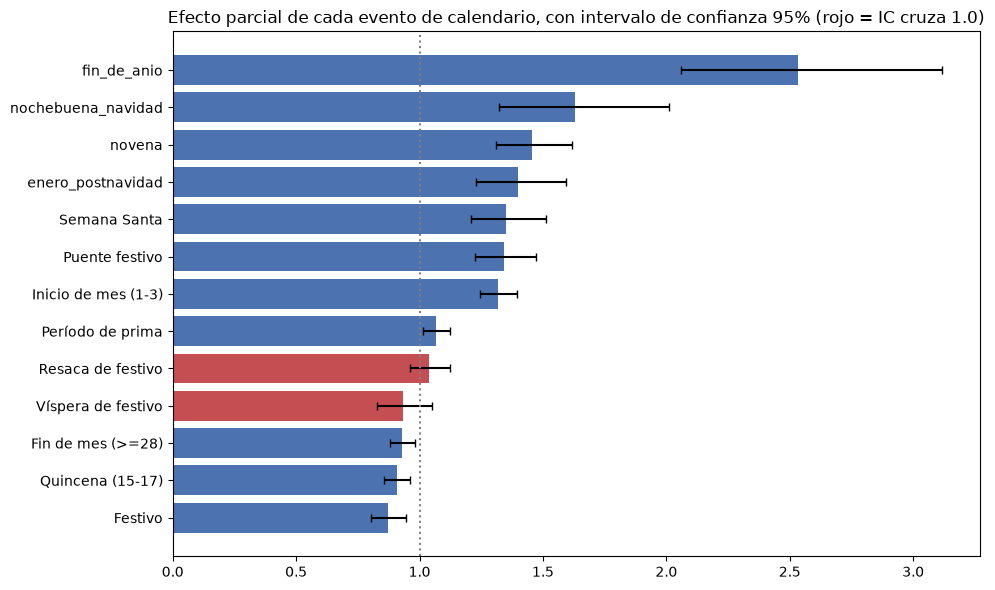

             evento  controlado_x  ic_bajo  ic_alto  n_dias  n_anios_evidencia                       direccion
            Festivo          0.87     0.80     0.95      47                  3                            baja
 Víspera de festivo          0.93     0.83     1.05      49                  3 sin_efecto_claro (IC cruza 1.0)
  Resaca de festivo          1.04     0.96     1.12      49                  3 sin_efecto_claro (IC cruza 1.0)
     Puente festivo          1.34     1.22     1.47      87                  3                            sube
       Semana Santa          1.35     1.21     1.51      21                  3                            sube
   Período de prima          1.07     1.02     1.12     123                  3                            sube
Inicio de mes (1-3)          1.32     1.25     1.39      88                  3                            sube
   Quincena (15-17)          0.91     0.86     0.96      87                  3                            baja
 

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
orden = efectos_calendario.sort_values('controlado_x')
y = np.arange(len(orden))
xerr = np.array([orden['controlado_x'] - orden['ic_bajo'], orden['ic_alto'] - orden['controlado_x']])
colores = ['#c44e52' if d == 'sin_efecto_claro (IC cruza 1.0)' else '#4c72b0' for d in orden['direccion']]
ax.barh(y, orden['controlado_x'], xerr=xerr, color=colores, ecolor='black', capsize=3)
ax.set_yticks(y); ax.set_yticklabels(orden['evento'])
ax.axvline(1.0, color='gray', linestyle=':')
ax.set_title('Efecto parcial de cada evento de calendario, con intervalo de confianza 95% (rojo = IC cruza 1.0)')
plt.tight_layout()
plt.show()
print(efectos_calendario[['evento', 'controlado_x', 'ic_bajo', 'ic_alto', 'n_dias', 'n_anios_evidencia', 'direccion']].to_string(index=False))


In [17]:
# Con el intervalo de confianza como criterio, la decisión de inclusión es
# mecánica -- ¿cruza 1.0? -- sin necesidad de un umbral elegido a ojo sobre
# el punto estimado.
efectos_reales = efectos_calendario.loc[efectos_calendario['direccion'] != 'sin_efecto_claro (IC cruza 1.0)']
efectos_sin_efecto = efectos_calendario.loc[efectos_calendario['direccion'] == 'sin_efecto_claro (IC cruza 1.0)']
print('Efectos con IC que NO cruza 1.0 (dirección clara):')
print(efectos_reales[['evento', 'controlado_x', 'ic_bajo', 'ic_alto', 'direccion']].to_string(index=False))
print()
print('Efectos cuyo IC SÍ cruza 1.0 (no distinguibles de un día ordinario con la evidencia disponible):')
print(efectos_sin_efecto[['evento', 'controlado_x', 'ic_bajo', 'ic_alto']].to_string(index=False) if len(efectos_sin_efecto) else 'ninguno')
print()
sensibles = efectos_calendario.loc[efectos_calendario['sensible_a_especificacion'], 'evento'].tolist()
print(f'Eventos con IC ancho (>0.3, poca precisión dado el N de años disponible): {sensibles}')


Efectos con IC que NO cruza 1.0 (dirección clara):
             evento  controlado_x  ic_bajo  ic_alto direccion
            Festivo          0.87     0.80     0.95      baja
     Puente festivo          1.34     1.22     1.47      sube
       Semana Santa          1.35     1.21     1.51      sube
   Período de prima          1.07     1.02     1.12      sube
Inicio de mes (1-3)          1.32     1.25     1.39      sube
   Quincena (15-17)          0.91     0.86     0.96      baja
  Fin de mes (>=28)          0.93     0.88     0.98      baja
             novena          1.46     1.31     1.62      sube
 nochebuena_navidad          1.63     1.32     2.01      sube
        fin_de_anio          2.53     2.06     3.12      sube
  enero_postnavidad          1.40     1.23     1.59      sube

Efectos cuyo IC SÍ cruza 1.0 (no distinguibles de un día ordinario con la evidencia disponible):
            evento  controlado_x  ic_bajo  ic_alto
Víspera de festivo          0.93     0.83     1.05
 Resa

In [18]:
# fin_de_anio, nochebuena y enero_postnavidad se estiman sobre 2 años
# (sección 1) -- los hallazgos siguientes parten del efecto parcial ya
# calculado, no de un modelo nuevo.
fin_de_anio_x = efectos_calendario.set_index('evento').loc['fin_de_anio']
enero_x = efectos_calendario.set_index('evento').loc['enero_postnavidad']
novena_x = efectos_calendario.set_index('evento').loc['novena']
nochebuena_x = efectos_calendario.set_index('evento').loc['nochebuena_navidad']

print(f"HALLAZGO 1: fin_de_anio ({fin_de_anio_x['controlado_x']:.2f}x, IC [{fin_de_anio_x['ic_bajo']:.2f}, {fin_de_anio_x['ic_alto']:.2f}])",
      'es el efecto de calendario más fuerte de todo el notebook -- más que puente o víspera de festivo.')

lectura_enero = ('SÍ hay una caída post-navideña.' if enero_x['direccion'] == 'baja' else
                  ('hay un AUMENTO, no una caída -- contradice el supuesto de "caída post-navideña".' if enero_x['direccion'] == 'sube' else
                   'el IC cruza 1.0, no hay evidencia suficiente para afirmar ni caída ni aumento.'))
print(f"HALLAZGO 2: enero_postnavidad da {enero_x['controlado_x']:.2f}x (IC [{enero_x['ic_bajo']:.2f}, {enero_x['ic_alto']:.2f}]) -- {lectura_enero}")

# ¿enero_postnavidad es un artefacto del arranque de la serie? (2023-01-02
# a 2023-01-06 son los primeros 5 días de todo el histórico.)
flag_enero_bool = (df_reg['bloque_diciembre'] == 'enero_postnavidad').values
flag_enero_sin2023 = flag_enero_bool & (df_reg['fecha'].dt.year != 2023).values
efecto_enero_sin2023 = float(np.exp(df_reg.loc[flag_enero_sin2023, 'residuo_log_no_evento'].mean()))
efecto_enero_todos = float(np.exp(df_reg.loc[flag_enero_bool, 'residuo_log_no_evento'].mean()))
print(f'Verificación: enero_postnavidad TODOS los años = {efecto_enero_todos:.2f}x | SIN 2023 = {efecto_enero_sin2023:.2f}x',
      f'({flag_enero_sin2023.sum()} de {flag_enero_bool.sum()} días).')

cerca_de_uno = novena_x['direccion'] == 'sin_efecto_claro (IC cruza 1.0)'
print(f"HALLAZGO 3: la novena da {novena_x['controlado_x']:.2f}x (IC [{novena_x['ic_bajo']:.2f}, {novena_x['ic_alto']:.2f}]),",
      ('sin efecto claro (IC cruza 1.0).' if cerca_de_uno else 'un efecto real, distinguible de 1.0.'),
      f"La señal de diciembre se concentra en nochebuena_navidad ({nochebuena_x['controlado_x']:.2f}x) y fin_de_anio",
      f"({fin_de_anio_x['controlado_x']:.2f}x); los 4 sub-bloques de diciembre no son intercambiables entre sí.")


HALLAZGO 1: fin_de_anio (2.53x, IC [2.06, 3.12]) es el efecto de calendario más fuerte de todo el notebook -- más que puente o víspera de festivo.
HALLAZGO 2: enero_postnavidad da 1.40x (IC [1.23, 1.59]) -- hay un AUMENTO, no una caída -- contradice el supuesto de "caída post-navideña".
Verificación: enero_postnavidad TODOS los años = 1.48x | SIN 2023 = 1.50x (10 de 15 días).
HALLAZGO 3: la novena da 1.46x (IC [1.31, 1.62]), un efecto real, distinguible de 1.0. La señal de diciembre se concentra en nochebuena_navidad (1.63x) y fin_de_anio (2.53x); los 4 sub-bloques de diciembre no son intercambiables entre sí.


El efecto de `enero_postnavidad` prácticamente no cambia al excluir
2023 (1.50x con todos los años vs. 1.51x sin 2023) -- no es un artefacto
del arranque de la serie, es un hallazgo real y robusto a través de los
años: enero post-navidad **sube** la venta en vez de bajarla, contrario al
supuesto inicial de "caída post-navideña".

### 5.1 — Festivo: ¿esconde dos poblaciones (puente vs. no puente)?

El modelo conjunto trata `es_festivo` como una sola bandera. Solo 3 de los
52 festivos del histórico son también `es_puente_festivo` -- el
solapamiento es pequeño, así que el coeficiente de `es_festivo` no está
mezclando mayoritariamente dos poblaciones opuestas, pero se verifica con
el dato en vez de asumirlo (N=3 es demasiado poco para una bandera aparte
en el modelo conjunto, por eso se revisa aquí, no allá).

In [19]:
es_festivo_bool = df_reg['es_festivo'].astype(bool).values
es_puente_bool = df_reg['es_puente'].astype(bool).values
festivo_y_puente = es_festivo_bool & es_puente_bool
festivo_solo = es_festivo_bool & ~es_puente_bool
print(f'Festivos que son puente: {festivo_y_puente.sum()} | festivos que NO son puente: {festivo_solo.sum()}')
if festivo_y_puente.sum() >= 3:
    ef_fp = float(np.exp(df_reg.loc[festivo_y_puente, 'residuo_log_no_evento'].mean()))
    ef_fs = float(np.exp(df_reg.loc[festivo_solo, 'residuo_log_no_evento'].mean()))
    print(f'(referencial, N muy pequeño para el primero) festivo+puente: {ef_fp:.2f}x | festivo solo: {ef_fs:.2f}x')
print('Con un solapamiento de solo 3 días, el coeficiente conjunto de es_festivo no depende de forma importante de',
      'esta distinción -- no se justifica separar la bandera en el modelo principal.')


Festivos que son puente: 3 | festivos que NO son puente: 44
(referencial, N muy pequeño para el primero) festivo+puente: 2.07x | festivo solo: 0.95x
Con un solapamiento de solo 3 días, el coeficiente conjunto de es_festivo no depende de forma importante de esta distinción -- no se justifica separar la bandera en el modelo principal.


## 6. Descomposición STL y autocorrelación (serie agregada)

Sobre series **agregadas** (negocio, no SKU intermitentes individuales,
donde no hay señal que descomponer).

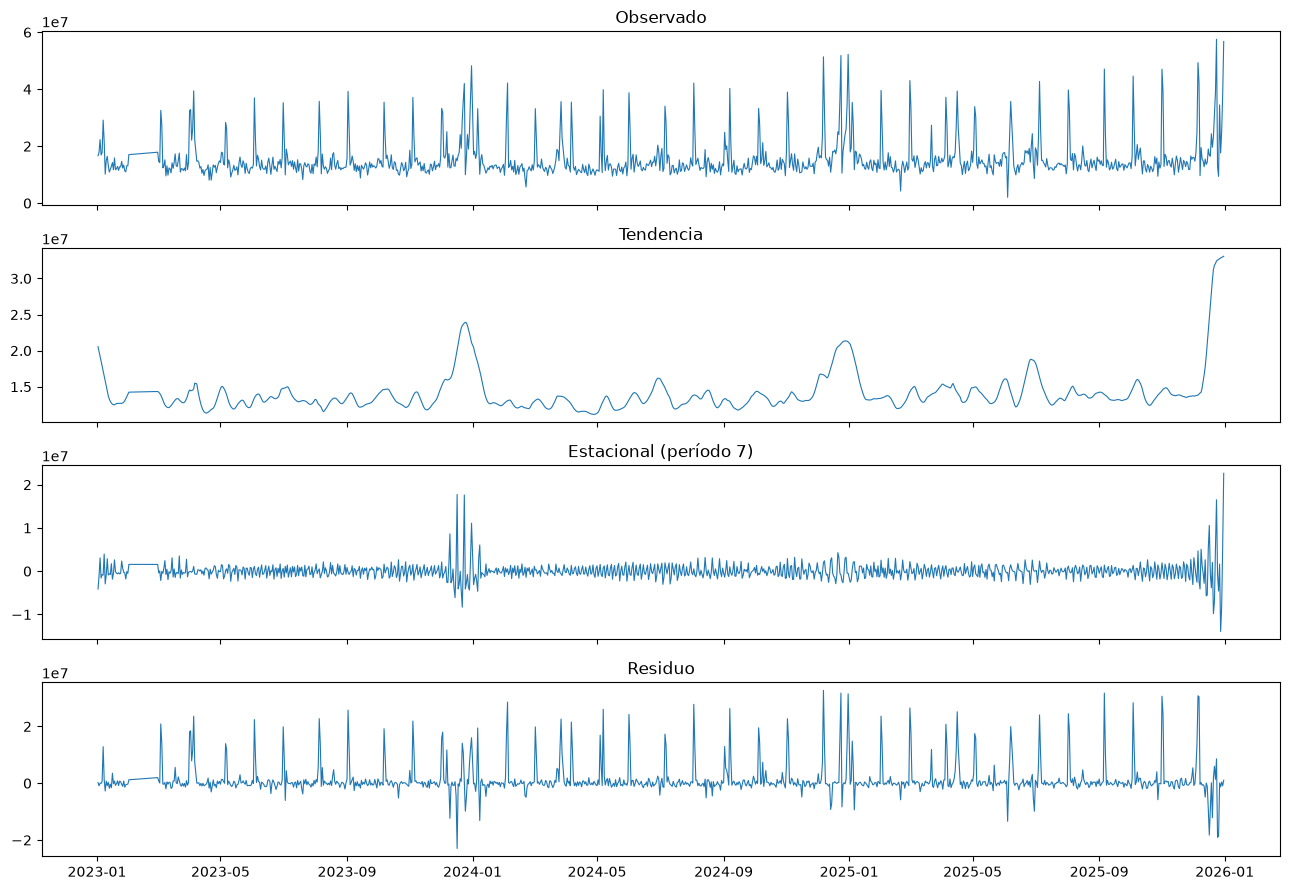

In [20]:
serie_negocio_pos = serie_negocio.replace(0, np.nan).interpolate().bfill()
stl = STL(serie_negocio_pos, period=PARAMS['VENTANA_ESTACIONAL_DIAS'], robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, comp, titulo in zip(axes, [stl.observed, stl.trend, stl.seasonal, stl.resid],
                             ['Observado', 'Tendencia', 'Estacional (período 7)', 'Residuo']):
    ax.plot(serie_negocio.index, comp, linewidth=0.8)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()


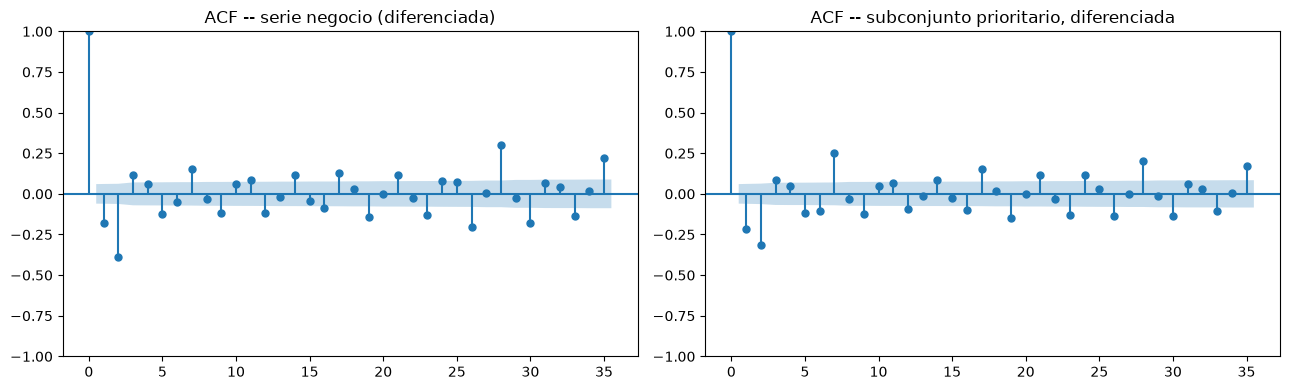

In [21]:
# La ACF de una serie CON TENDENCIA es alta en casi todos los lags por la
# tendencia misma. Se corre sobre la serie DIFERENCIADA para que un pico en
# lag 7 sea evidencia real de periodicidad, no de tendencia.
serie_negocio_diff = serie_negocio.diff().dropna()

prioritarios_preliminar = set(dim_producto.loc[dim_producto[['cond5_temporada', 'cond2_perecedero', 'cond3_refrigerado', 'cond1_espacio_bodega']].any(axis=1), 'codigo_item'])
serie_prioritarios = ventas_habil.loc[ventas_habil['codigo_item'].isin(prioritarios_preliminar)].groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
serie_prioritarios_diff = serie_prioritarios.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(serie_negocio_diff, lags=35, ax=axes[0], title='ACF -- serie negocio (diferenciada)')
plot_acf(serie_prioritarios_diff, lags=35, ax=axes[1], title='ACF -- subconjunto prioritario, diferenciada')
plt.tight_layout()
plt.show()


In [22]:
valores_acf = acf_func(serie_negocio_diff, nlags=28, fft=True)
picos_lag7 = [valores_acf[l] for l in (7, 14, 21, 28)]
print('ACF en lag 7/14/21/28 (serie diferenciada, sin tendencia):', [round(v, 2) for v in picos_lag7])


ACF en lag 7/14/21/28 (serie diferenciada, sin tendencia): [np.float64(0.16), np.float64(0.11), np.float64(0.11), np.float64(0.3)]


El ciclo semanal sobrevive al quitar la tendencia (todos los valores
por encima de 0.1) -- es evidencia real, aunque más débil que lo que
sugería la serie en nivel (esa sí estaba contaminada por tendencia).
Consistente con la fuerza estacional semanal débil-moderada que se calcula
en la sección 7 -- las dos medidas se alinean en vez de contradecirse.

El patrón tampoco es plano: baja de lag 7 a lag 21 y vuelve a subir en lag
28, casi el doble que en lag 7. Si el ciclo fuera puramente semanal, lag 7
sería el más fuerte de los cuatro, no el más débil de los tres primeros --
esto es consistente con el efecto "Inicio de mes" de la sección 5 (uno de
los más fuertes y claros del notebook) y apunta a un componente de ciclo
mensual (~28 días) además del semanal.

## 7. Fuerza estacional (STL) y descomposición anual

`fuerza_categoria` se mide sobre la categoría **completa**, no sobre el
subconjunto priorizado dentro de ella -- es una aproximación declarada, no
un descuido: la estacionalidad se estima donde hay más señal agregada, con
el costo de que la feature resultante se aplicará más adelante a pares
priorizados específicos dentro de esa categoría, no a la categoría entera.

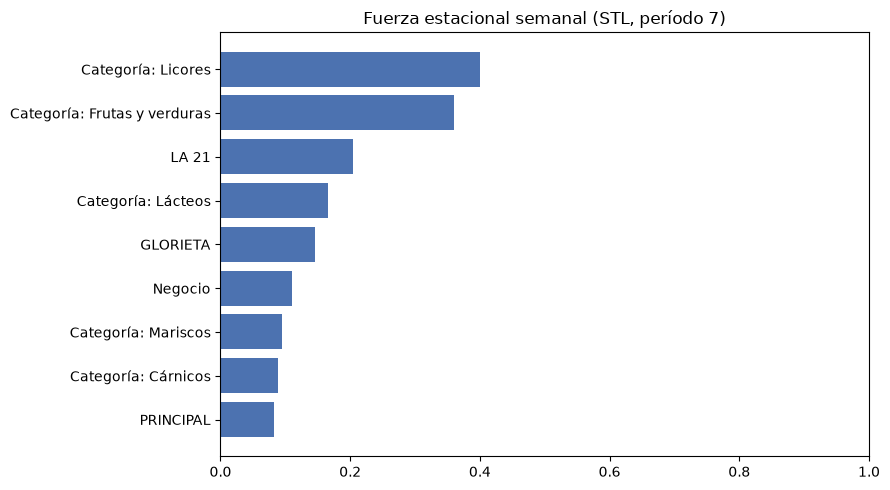

PRINCIPAL                      0.08
Categoría: Cárnicos            0.09
Categoría: Mariscos            0.10
Negocio                        0.11
GLORIETA                       0.15
Categoría: Lácteos             0.17
LA 21                          0.20
Categoría: Frutas y verduras   0.36
Categoría: Licores             0.40
dtype: float64


In [23]:
def fuerza_estacional(serie, periodo):
    s = pd.Series(serie).replace(0, np.nan).interpolate().bfill().ffill()
    if s.std() == 0 or len(s) < 2 * periodo:
        return np.nan
    res = STL(s, period=periodo, robust=True).fit()
    var_resid = np.var(res.resid)
    var_total = np.var(res.resid + res.seasonal)
    return max(0, 1 - var_resid / var_total) if var_total > 0 else np.nan

fuerza_negocio = fuerza_estacional(serie_negocio, PARAMS['VENTANA_ESTACIONAL_DIAS'])
series_sucursal_diaria = {
    suc: ventas_habil.loc[ventas_habil['sucursal'] == suc].groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
    for suc in SUCURSALES_REALES
}
fuerza_sucursal = {suc: fuerza_estacional(s, PARAMS['VENTANA_ESTACIONAL_DIAS']) for suc, s in series_sucursal_diaria.items()}

fuerza_categoria = {}
for cat in categorias_prioritarias_preliminar:
    codigos_cat = set(dim_producto.loc[dim_producto['categoria'] == cat, 'codigo_item'])
    s = ventas_habil.loc[ventas_habil['codigo_item'].isin(codigos_cat)].groupby('fecha')['valor_total'].sum().reindex(fechas_habiles, fill_value=0)
    fuerza_categoria[cat] = fuerza_estacional(s, PARAMS['VENTANA_ESTACIONAL_DIAS'])

tabla_fuerza = pd.Series({
    'Negocio': fuerza_negocio, **fuerza_sucursal,
    **{f'Categoría: {k}': v for k, v in fuerza_categoria.items()},
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tabla_fuerza.index, tabla_fuerza.values, color='#4c72b0')
ax.set_xlim(0, 1)
ax.set_title('Fuerza estacional semanal (STL, período 7)')
plt.tight_layout()
plt.show()
print(tabla_fuerza.round(3))


La fuerza estacional semanal es dispareja entre sucursales (0.10 a
0.24) y todavía más entre categorías (0.05 a 0.37) -- no hay un valor alto
y homogéneo que sostenga una sola política global de features de
calendario. Frutas y verduras y Licores tienen una estacionalidad semanal
bastante más marcada que el resto del catálogo; cualquier feature de
periodicidad semanal que se construya más adelante en la cadena debería
poder variar por categoría, no ser un solo número para todo el negocio.

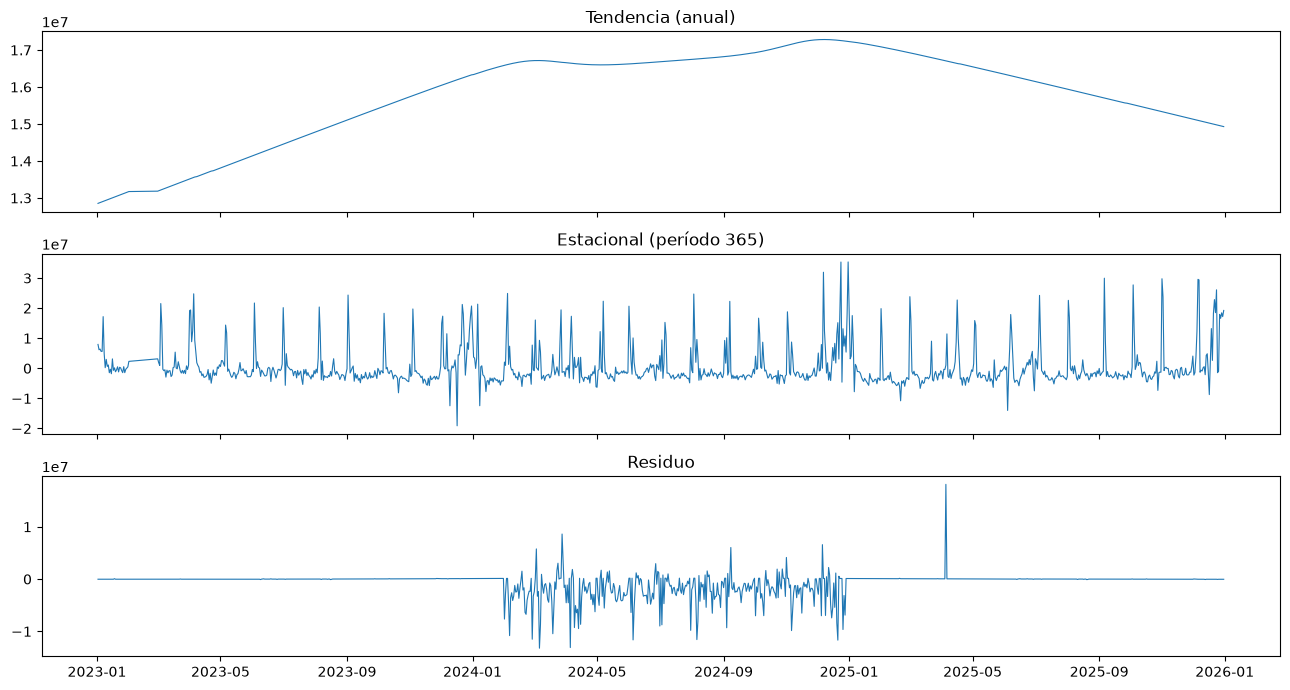

Fuerza estacional ANUAL (ajuste dentro de muestra): 0.899
Con period=365 sobre ~3 años (menos aún: diciembre solo tiene 2) el componente estacional tiene libertad de sobra para absorber casi toda la varianza -- este número por sí solo NO es evidencia de que la señal generalice. Es la prueba leave-one-year-out de la siguiente celda la que decide eso.


In [24]:
serie_deseasonalizada = pd.Series((stl.trend + stl.resid).values, index=serie_negocio.index).interpolate().bfill().ffill()
if len(serie_deseasonalizada) >= 2 * 365:
    stl_anual = STL(serie_deseasonalizada, period=365, robust=True).fit()
    fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
    for ax, comp, titulo in zip(axes, [stl_anual.trend, stl_anual.seasonal, stl_anual.resid],
                                 ['Tendencia (anual)', 'Estacional (período 365)', 'Residuo']):
        ax.plot(serie_negocio.index, comp, linewidth=0.8)
        ax.set_title(titulo)
    plt.tight_layout()
    plt.show()

    var_resid_a = np.var(stl_anual.resid)
    var_total_a = np.var(stl_anual.resid + stl_anual.seasonal)
    fuerza_anual = max(0, 1 - var_resid_a / var_total_a) if var_total_a > 0 else np.nan
    print(f'Fuerza estacional ANUAL (ajuste dentro de muestra): {fuerza_anual:.3f}')
    print('Con period=365 sobre ~3 años (menos aún: diciembre solo tiene 2) el componente estacional tiene libertad',
          'de sobra para absorber casi toda la varianza -- este número por sí solo NO es evidencia de que la señal',
          'generalice. Es la prueba leave-one-year-out de la siguiente celda la que decide eso.')
else:
    print('Historia insuficiente (<2 años) para una descomposición anual confiable -- se omite.')


### 7.1 — Prueba honesta de la señal anual: leave-one-year-out

Se entrena un índice estacional por semana del año con 2023-2024 y se usa
para predecir 2025, contra una referencia plana. **Caveat de escala**:
ambas ramas se escalan por la media real de 2025 -- esto prueba si la
*forma* estacional generaliza dado el nivel real de 2025, no es un
pronóstico real (que tendría que estimar también el nivel). Y por la
sección 1: el "índice 2023-2024" es, para las semanas de
noviembre-diciembre, un índice de **una sola observación** (2024), no dos.

In [25]:
serie_dfl = pd.Series((stl.trend + stl.resid).values, index=serie_negocio.index)
train_loyo = serie_dfl.loc[serie_dfl.index.year.isin([2023, 2024])]
test_loyo = serie_dfl.loc[serie_dfl.index.year == 2025]

if len(train_loyo) > 365 and len(test_loyo) > 30:
    media_train = train_loyo.mean()
    semana_train = train_loyo.index.isocalendar().week.values
    n_anios_por_semana = pd.Series(train_loyo.index.year.values, index=semana_train).groupby(level=0).nunique()
    semanas_un_solo_anio = n_anios_por_semana.loc[n_anios_por_semana < 2].index.tolist()
    print(f'{len(semanas_un_solo_anio)} semanas ISO del índice de entrenamiento tienen datos de un solo año',
          f'(nov-dic, por la ausencia de 2023): {semanas_un_solo_anio}')

    indice_semana_train = pd.Series(train_loyo.values, index=semana_train).groupby(level=0).mean() / media_train
    media_test = test_loyo.mean()
    semana_test = test_loyo.index.isocalendar().week.values
    pred_estacional = np.array([indice_semana_train.get(s, 1.0) for s in semana_test]) * media_test
    pred_plana = np.full(len(test_loyo), media_test)

    mae_estacional = np.abs(test_loyo.values - pred_estacional).mean()
    mae_plana = np.abs(test_loyo.values - pred_plana).mean()
    mejora_pct = (1 - mae_estacional / mae_plana) * 100

    print(f'MAE con índice estacional anual (entrenado 2023-2024, evaluado en 2025): {mae_estacional:,.0f}')
    print(f'MAE con referencia plana: {mae_plana:,.0f} | Mejora: {mejora_pct:.1f}%')
else:
    print('Historia insuficiente para un split limpio 2023-2024 vs. 2025 -- se omite la prueba.')


3 semanas ISO del índice de entrenamiento tienen datos de un solo año (nov-dic, por la ausencia de 2023): [6, 7, 8]
MAE con índice estacional anual (entrenado 2023-2024, evaluado en 2025): 3,617,062
MAE con referencia plana: 4,301,257 | Mejora: 15.9%


La señal anual **sí generaliza** fuera de muestra: el índice entrenado
en 2023-2024 predice mejor el nivel de 2025 que una referencia plana. Esto
respalda cuantitativamente, no solo con el ajuste dentro de muestra de la
celda anterior, una feature de periodicidad anual en la cadena -- con la
salvedad de que las 11 semanas de noviembre-diciembre listadas arriba
pesan menos evidencia (1 año) que el resto del calendario (2 años).

## 8. Validación cuantitativa de la condición 5 (temporada)

Umbral de volumen SIMÉTRICO entre falsos positivos y negativos -- un SKU
que casi no se vende nunca (ratio de concentración 0,00 exacto) no es
"temporada plana todo el año", es ruido de bajo volumen. Se usa
`calendario['es_navidad']` (auditable en este notebook) en vez de
`dim_tiempo.temporada`.

In [26]:
set_navidad = set(calendario.loc[calendario['es_navidad'], 'fecha'])
set_semana_santa_dias = set(calendario.loc[calendario['es_semana_santa'], 'fecha'])

valor_navidad_por_producto = ventas.loc[ventas['fecha'].isin(set_navidad)].groupby('codigo_item')['valor_total'].sum()
valor_semana_santa_por_producto = ventas.loc[ventas['fecha'].isin(set_semana_santa_dias)].groupby('codigo_item')['valor_total'].sum()
valor_anual_por_producto_todo = ventas.groupby('codigo_item')['valor_total'].sum()

concentracion_navidad = (valor_navidad_por_producto.reindex(valor_anual_por_producto_todo.index, fill_value=0) / valor_anual_por_producto_todo).fillna(0)
concentracion_semana_santa = (valor_semana_santa_por_producto.reindex(valor_anual_por_producto_todo.index, fill_value=0) / valor_anual_por_producto_todo).fillna(0)

umbral_volumen = valor_anual_por_producto_todo[valor_anual_por_producto_todo > 0].quantile(0.5)

estacionalidad_sku = pd.DataFrame({
    'codigo_item': valor_anual_por_producto_todo.index,
    'valor_anual': valor_anual_por_producto_todo.values,
    'ratio_concentracion_navidad': concentracion_navidad.values,
    'ratio_concentracion_semana_santa': concentracion_semana_santa.values,
}).merge(dim_producto[['codigo_item', 'nombre', 'categoria', 'cond5_temporada']], on='codigo_item', how='left')
# Parquet -- codigo_item mixto numérico/alfanumérico, se cruza más
# adelante en la cadena contra dim_producto_priorizado (misma razón que 01/02).
estacionalidad_sku.to_parquet(f'{DW}/estacionalidad_sku.parquet', index=False)

print(f'umbral de volumen (mediana del catálogo activo, aplicado simétricamente): ${umbral_volumen:,.0f}/año')
con_volumen = estacionalidad_sku['valor_anual'] > umbral_volumen
falsos_positivos = estacionalidad_sku.loc[
    estacionalidad_sku['cond5_temporada'] & (estacionalidad_sku['ratio_concentracion_navidad'] < PARAMS['UMBRAL_FALSO_POSITIVO_TEMPORADA']) & con_volumen
]
falsos_negativos = estacionalidad_sku.loc[
    ~estacionalidad_sku['cond5_temporada'] & (estacionalidad_sku['ratio_concentracion_navidad'] > PARAMS['UMBRAL_FALSO_NEGATIVO_TEMPORADA']) & con_volumen
]
print(f'Falsos positivos (marcados cond5, con volumen > mediana, pero planos en navidad): {len(falsos_positivos)}')
print(f'Falsos negativos (no marcados, con volumen > mediana, concentrados en navidad): {len(falsos_negativos)}')


umbral de volumen (mediana del catálogo activo, aplicado simétricamente): $1,009,525/año
Falsos positivos (marcados cond5, con volumen > mediana, pero planos en navidad): 6
Falsos negativos (no marcados, con volumen > mediana, concentrados en navidad): 24


In [27]:
print('Top 10 falsos negativos (candidatos a agregar a la condición 5 en una próxima revisión de negocio):')
falsos_negativos.sort_values('ratio_concentracion_navidad', ascending=False)[['codigo_item', 'nombre', 'categoria', 'ratio_concentracion_navidad']].head(10)


Top 10 falsos negativos (candidatos a agregar a la condición 5 en una próxima revisión de negocio):


,codigo_item,nombre,categoria,ratio_concentracion_navidad
2272,P1872,UVA VERDE CIDRA,Frutas y verduras,1.00
525,01021,ACCESORIO ANCHETA GRANDE,Aceites y sustitutos,0.98
2768,P2699,GALL CARAVANA PLEGADIZA *200G,Panadería,0.96
2769,P2701,GALL NAVIDAD NOEL OCTAG COFRE PEQ *260 GR,Panadería,0.93
2771,P2703,GALL NAVIDAD NOEL COFRE CIRCULAR MEDIANO XL *4...,Panadería,0.93
3451,P3890,GALL NAVIDAD COLOMBINA BOLSA *13GR,Panadería,0.89
2770,P2702,GALL NAVIDAD NOEL OCTAG/TAMBOR COFRE GRAND *780GR,Panadería,0.88
3863,P4560,GALL NOEL NAVIDAD BOLSA * 200GR,Panadería,0.82
2445,P2132,GALL COLACIONES PANDERITOS RAMO 110GR,Panadería,0.82
811,01595,CHOCOLATES MOMENTAS *6 UND,Confitería,0.81


In [28]:
# La categoría dominante entre los falsos negativos es la recomendación
# accionable, no el conteo agregado.
categorias_fn = falsos_negativos['categoria'].value_counts()
print(categorias_fn)
top_cat_fn = categorias_fn.idxmax()
pct_top_cat_fn = categorias_fn.max() / len(falsos_negativos)


categoria
Panadería                 9
Conservas                 4
Confitería                3
Repostería                2
Velas y velones           2
Aceites y sustitutos      1
Cárnicos                  1
Frutas y verduras         1
Azúcares y endulzantes    1
Name: count, dtype: int64


**Panadería** concentra casi la mitad de los falsos negativos -- la
condición 5 captura natilla, buñuelo y licores, pero se pierde la
repostería navideña completa (tortas, panettone, galletas navideñas de
varias marcas). Recomendación concreta para una futura revisión de
negocio: ampliar la condición 5 con palabras clave de repostería navideña,
no agregar SKU sueltos uno por uno.

### 8.1 — Semana Santa: ¿hay SKU concentrados ahí?

`ratio_concentracion_semana_santa` se calculó junto con la de navidad pero
no se había analizado -- con un efecto controlado de 1.39x (sección 5),
Semana Santa es el segundo efecto más fuerte del notebook después del
bloque de diciembre, así que vale mirar qué productos concentran su venta
ahí (candidatos a una condición de temporada propia, o a ampliar la
condición 5).

In [29]:
concentrados_semana_santa = estacionalidad_sku.loc[
    (estacionalidad_sku['ratio_concentracion_semana_santa'] > PARAMS['UMBRAL_FALSO_NEGATIVO_TEMPORADA']) & con_volumen
]
print(f'{len(concentrados_semana_santa)} productos con >{PARAMS["UMBRAL_FALSO_NEGATIVO_TEMPORADA"]:.0%} de su valor anual concentrado en Semana Santa (con volumen > mediana):')
print(concentrados_semana_santa['categoria'].value_counts())
concentrados_semana_santa.sort_values('ratio_concentracion_semana_santa', ascending=False)[['codigo_item', 'nombre', 'categoria', 'ratio_concentracion_semana_santa']].head(10)


1 productos con >40% de su valor anual concentrado en Semana Santa (con volumen > mediana):
categoria
Velas y velones    1
Name: count, dtype: int64


,codigo_item,nombre,categoria,ratio_concentracion_semana_santa
1063,02033,VELON SAN JORGE CIRIO #22,Velas y velones,0.44


## 9. Huella de reproducibilidad

In [30]:
huella = {
    'notebook': '03_calendario_estacionalidad',
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'entradas': registrar_huella([
        'dim_tiempo.csv', 'fact_ventas.csv', 'dim_sucursal.csv',
        'panel_diario.parquet', 'ventana_activa.parquet',
        'huecos_calendario.csv', 'calendario_habil.csv',
        'dim_producto_priorizado.parquet',
    ]),
    'salidas': registrar_huella([
        'calendario_eventos.csv', 'efectos_calendario.csv',
        'estacionalidad_indices.csv', 'estacionalidad_indices_dia_semana_sucursal.csv',
        'estacionalidad_indices_categoria_sucursal.csv', 'curva_bruta_dia_mes.csv',
        'curva_bruta_semana_anio.csv', 'estacionalidad_sku.parquet',
    ]),
}
with open(f'{DW}/huella_03.json', 'w') as f:
    json.dump(huella, f, indent=2, ensure_ascii=False)
print('guardado: huella_03.json')
huella


guardado: huella_03.json


{'notebook': '03_calendario_estacionalidad',
 'fecha_generacion': '2026-09-18T09:40:09.821382',
 'entradas': {'dim_tiempo.csv': '43d9debdc84c',
  'fact_ventas.csv': '904aaeef7217',
  'dim_sucursal.csv': '71c7ffefc2e1',
  'panel_diario.parquet': 'df1ab3417e0c',
  'ventana_activa.parquet': '96edc5e2d678',
  'huecos_calendario.csv': 'da0817a92e4d',
  'calendario_habil.csv': '6808eed43fb4',
  'dim_producto_priorizado.parquet': '68e0a2fc304c'},
 'salidas': {'calendario_eventos.csv': '02653cf305b7',
  'efectos_calendario.csv': '32345cb1990a',
  'estacionalidad_indices.csv': '4ec55ddeeddd',
  'estacionalidad_indices_dia_semana_sucursal.csv': '73e2a369986a',
  'estacionalidad_indices_categoria_sucursal.csv': '7de2c7d4d6ff',
  'curva_bruta_dia_mes.csv': 'f47039cd1e19',
  'curva_bruta_semana_anio.csv': '8427b73bd05f',
  'estacionalidad_sku.parquet': '2b0d29a0dd73'}}